In [1]:
import pandas as pd

file_name = "4350_vimeo_videos.parquet"

In [10]:
df = pd.read_parquet(file_name)

In [11]:
df = df.loc[~df["transcript_content"].isna()]

In [12]:
# df.head()
# print(df.columns)
print('-'*20)
df.info()

--------------------
<class 'pandas.core.frame.DataFrame'>
Index: 3344 entries, 2 to 4349
Data columns (total 45 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   uri                          3344 non-null   object
 1   name                         3344 non-null   object
 2   description                  0 non-null      object
 3   type                         3344 non-null   object
 4   link                         3344 non-null   object
 5   player_embed_url             3344 non-null   object
 6   duration                     3344 non-null   int64 
 7   width                        3344 non-null   int64 
 8   language                     3344 non-null   object
 9   height                       3344 non-null   int64 
 10  embed                        3344 non-null   object
 11  created_time                 3344 non-null   object
 12  modified_time                3344 non-null   object
 13  release_time     

In [54]:
import re

# Clean the transcript content
def clean_transcript(transcript):
    if not transcript:
        return None
    # Remove WEBVTT header and timestamps
    cleaned = re.sub(r'WEBVTT\n\n', '', transcript)  # Remove WEBVTT header
    cleaned = re.sub(r'\d+\n\d{2}:\d{2}:\d{2}\.\d{3} --> \d{2}:\d{2}:\d{2}\.\d{3}\n', '', cleaned)  # Remove timestamps
    cleaned = re.sub(r"\b[Uu][mh]\b[.,!?;]*", "", cleaned) # Remove fillers
    cleaned = re.sub(r'\n+', ' ', cleaned)  # Replace multiple newlines with a single space
    cleaned = re.sub(r"\s\s+", " ", cleaned) # Remove extra whitespaces
    cleaned = cleaned.strip()  # Remove leading/trailing spaces
    return cleaned

def remove_fillers(transcript):
    cleaned = re.sub(r"\b[Uu][mh]\b[.,!?;]*", "", transcript)
    return cleaned

# Apply the cleaning function to the DataFrame
df['cleaned_transcript'] = df['transcript_content'].apply(clean_transcript)
# df["cleaned2"] = df["cleaned_transcript"].map(clean_transcript)

In [51]:
print("Left")
print(re.sub(r"\b[Uu][mh]\b[.,!?;]*", "", "Um... hello"))
print(re.sub(r"\b[Uu][mh]\b[.,!?;]*", "", "Um, hello"))
print(re.sub(r"\b[Uu][mh]\b[.,!?;]*", "", "Um hello"))
print(re.sub(r"\b[Uu][mh]\b[.,!?;]*", "", ". Uh, hello"))
print(re.sub(r"\b[Uu][mh]\b[.,!?;]*", "", ".Uh hello"))

Left
 hello
 hello
 hello
.  hello
. hello


In [ ]:
df.head()

In [19]:
import random
import os

In [18]:
random.randint(0, len(df)-1)

359

In [55]:
for _ in range(10):
    idx = random.randint(0, len(df)-1)
    fname = f"transcript{idx}_v2.txt"

    if os.path.exists(fname):
        os.remove(fname)
    
    with open(fname, "a") as f:
        for col in ["name", "vtt_filename", "transcript_content", "cleaned_transcript"]:
            # print(f"{col}: {df.iloc[idx][col]}")
            # print("-"*100)
            f.write(f"{col}:\n")
            f.write(df.iloc[idx][col])
            f.write("\n")
            f.write("-"*100)
            f.write("\n")

In [21]:
df["transcript_len"] = df["cleaned_transcript"].map(lambda x: len(x))

In [25]:
df[["vtt_filename", "transcript_len"]].to_csv("transcript_names_lens.csv")

In [18]:
df = df.loc[~df["transcript_content"].isnull()]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3344 entries, 2 to 4349
Data columns (total 45 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   uri                          3344 non-null   object
 1   name                         3344 non-null   object
 2   description                  0 non-null      object
 3   type                         3344 non-null   object
 4   link                         3344 non-null   object
 5   player_embed_url             3344 non-null   object
 6   duration                     3344 non-null   int64 
 7   width                        3344 non-null   int64 
 8   language                     3344 non-null   object
 9   height                       3344 non-null   int64 
 10  embed                        3344 non-null   object
 11  created_time                 3344 non-null   object
 12  modified_time                3344 non-null   object
 13  release_time                 3344 non-

In [28]:
types = df["transcript_content"].map(lambda x: type(x))
types.value_counts()

transcript_content
<class 'str'>    3344
Name: count, dtype: int64

In [29]:
lengths = df["transcript_content"].map(lambda x: len(x))
lengths.describe()

count      3344.000000
mean      81002.195873
std       78788.119732
min          23.000000
25%       15187.750000
50%       50537.500000
75%      138289.750000
max      554683.000000
Name: transcript_content, dtype: float64

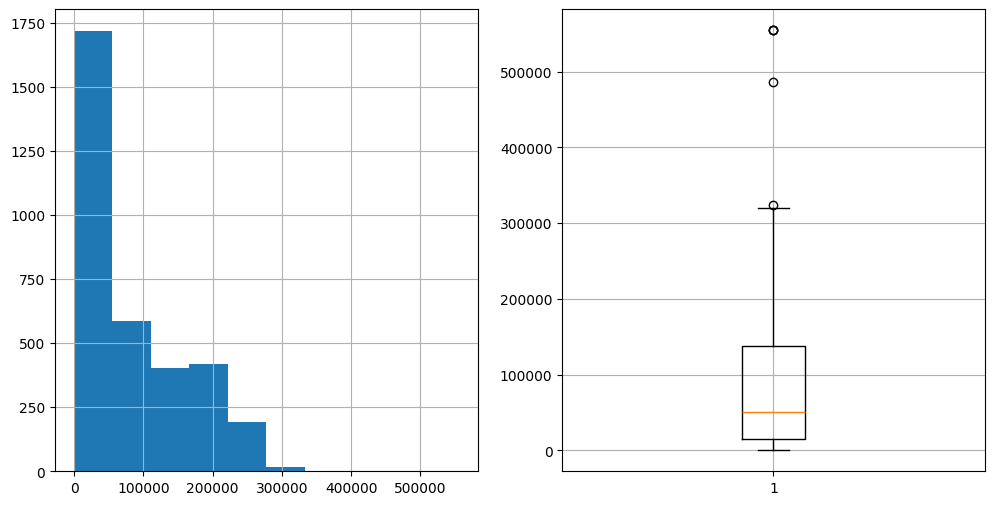

In [45]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(12,6))
# axs.boxplot(lengths)
axs[0].hist(lengths)
axs[0].grid()
axs[1].boxplot(lengths)
axs[1].grid()

In [60]:
cond = lengths < 30
cond = (lengths >=30) & (lengths < 100)
cond = (lengths >= 100) & (lengths < 200)
cond = (lengths >= 200) & (lengths < 300)
cond = (lengths >= 300) & (lengths < 1000)
cond = (lengths >= 1000) & (lengths < 2000)
print(f"Number of rows: {sum(cond)}")
print("-"*20)
for _, row in df.loc[cond].iterrows():
    print(row["transcript_content"])
    print('-'*20)
# .iloc[0]["transcript_content"]

Number of rows: 115
--------------------
WEBVTT

1
00:00:03.035 --> 00:00:03.895
Hi everyone.

2
00:00:03.895 --> 00:00:05.295
Thank you for joining tonight

3
00:00:05.475 --> 00:00:07.735
and, uh, we're excited to have this event.

4
00:00:07.955 --> 00:00:11.175
And I'm Adam, I'm the program manager from W Cloud Data.

5
00:00:11.955 --> 00:00:15.215
Uh, so today's topics is enterprise AI

6
00:00:15.555 --> 00:00:18.935
and uh, is the mainly focused on the data operations

7
00:00:18.935 --> 00:00:21.375
and the machine learning operations strategies.

8
00:00:22.195 --> 00:00:26.895
Uh, we will, we invite Lisa and is our special guest,

9
00:00:27.075 --> 00:00:28.975
and she, she will be the speaker tonight.

10
00:00:29.555 --> 00:00:32.775
She is the engineer and then now product manager.

11
00:00:33.275 --> 00:00:37.665
And from, uh, data, uh, Strat to,

12
00:00:38.325 --> 00:00:41.305
uh, from the, she now is a,

13
00:00:43.315 --> 00:00:48.085
Lisa is a data engineer and 